# Evidential Feasibility Demo（Jupyter 中文注释版）

核心问题：
**把 evidential 不确定性信号接入策略门控后，能否在 OOD 场景减少风险，同时不过度损失效率。**

运行顺序：
1. 核心代码
2. 参数设置并运行 `run(args)`
3. 查看表格与图

## 指标

- `OOD-AUROC`：越高越好，表示 ID/OOD 可分性强。
- `Collision`：越低越好，安全性更高。
- `Progress`：越高越好，效率更高。
- `Aggressive Rate`：策略激进程度。

我们关注的是 **安全-效率前沿**，不是单一分数。

In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ===================== 导读 =====================
# 该 demo 的核心目标：
# 1) 验证 Evidential 信号是否真的有信息量
# 2) 对比 CE 与 EDL 在 OOD 下的安全-效率权衡
# 3) 给出可行性证据（不是追求复杂场景还原）
# ---------------------------------------------------------------
# 代码模块：
# - 数据生成与拆分：build_splits
# - 模型训练：fit_model（CE/EDL）
# - 信号评估：evaluate_signal_quality
# - 策略仿真：sweep_threshold / choose_threshold_under_budget
# - 可视化：plot_frontiers / plot_bar_comparison
# ---------------------------------------------------------------

#!/usr/bin/env python3
"""
Simple feasibility demo: Evidential signal quality + safety-efficiency tradeoff.

Goal:
1) Verify whether evidential model provides useful uncertainty signal.
2) Verify whether using that signal in gating can improve safety with bounded efficiency loss.

No NavSim dependency; pure Python (numpy/autograd/scipy/matplotlib/seaborn/pandas).
"""

from __future__ import annotations

import argparse
import json
import os
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple

import autograd.numpy as anp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from autograd import grad
from autograd.extend import defvjp, primitive
from scipy.special import digamma as sp_digamma
from scipy.special import gammaln as sp_gammaln
from scipy.special import polygamma as sp_polygamma

warnings.filterwarnings("ignore", category=UserWarning)

METHOD_COLORS = {"ce": "#3B5B92", "edl": "#D94841"}
METHOD_LABELS = {"ce": "Softmax-CE", "edl": "Evidential-EDL"}


@primitive
def gammaln_p(x: anp.ndarray) -> anp.ndarray:
    return sp_gammaln(x)


defvjp(gammaln_p, lambda ans, x: lambda g: g * sp_digamma(x))


@primitive
def digamma_p(x: anp.ndarray) -> anp.ndarray:
    return sp_digamma(x)


defvjp(digamma_p, lambda ans, x: lambda g: g * sp_polygamma(1, x))


def stable_softplus(x: anp.ndarray) -> anp.ndarray:
    return anp.log1p(anp.exp(-anp.abs(x))) + anp.maximum(x, 0.0)


def relu(x: anp.ndarray) -> anp.ndarray:
    return anp.maximum(x, 0.0)


def softmax(logits: anp.ndarray) -> anp.ndarray:
    z = logits - anp.max(logits, axis=1, keepdims=True)
    e = anp.exp(z)
    return e / (anp.sum(e, axis=1, keepdims=True) + 1e-12)


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def one_hot_binary(y: np.ndarray) -> np.ndarray:
    out = np.zeros((y.shape[0], 2), dtype=np.float64)
    out[np.arange(y.shape[0]), y] = 1.0
    return out


def entropy_binary_prob(p_safe: np.ndarray) -> np.ndarray:
    p = np.clip(p_safe, 1e-12, 1.0 - 1e-12)
    return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))


def metric_auc_rank(y_true: np.ndarray, score: np.ndarray) -> float:
    y = y_true.astype(np.int64)
    pos = y == 1
    neg = y == 0
    n_pos = np.sum(pos)
    n_neg = np.sum(neg)
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(score, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, len(score) + 1)
    auc = (np.sum(ranks[pos]) - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)


def metric_ece_binary(y_true: np.ndarray, p_safe: np.ndarray, n_bins: int = 15) -> float:
    pred = (p_safe >= 0.5).astype(np.int64)
    conf = np.where(pred == 1, p_safe, 1.0 - p_safe)
    corr = (pred == y_true).astype(np.float64)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = y_true.shape[0]

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            mask = (conf >= lo) & (conf < hi)
        else:
            mask = (conf >= lo) & (conf <= hi)
        cnt = np.sum(mask)
        if cnt == 0:
            continue
        acc = np.mean(corr[mask])
        c = np.mean(conf[mask])
        ece += (cnt / n) * abs(acc - c)

    return float(ece)


def metric_brier_binary(y_true: np.ndarray, p_safe: np.ndarray) -> float:
    y = y_true.astype(np.float64)
    return float(np.mean((p_safe - y) ** 2))


def metric_nll_binary(y_true: np.ndarray, p_safe: np.ndarray) -> float:
    p = np.clip(p_safe, 1e-12, 1.0 - 1e-12)
    y = y_true.astype(np.float64)
    return float(-np.mean(y * np.log(p) + (1.0 - y) * np.log(1.0 - p)))


def true_safe_probability(x: np.ndarray, domain: str) -> np.ndarray:
    x1 = x[:, 0]
    x2 = x[:, 1]

    base = (
        1.25 * x1
        - 1.05 * x2
        + 0.9 * np.sin(1.3 * x1)
        - 0.65 * np.cos(1.1 * x2)
        - 0.22 * (x1**2 + x2**2)
        + 0.18 * x1 * x2
    )

    if domain == "id":
        z = base
    else:
        # Distribution shift: more complex and generally riskier for aggressive behavior.
        z = base - 0.55 + 0.55 * np.sin(0.8 * (x1 + x2)) - 0.25 * np.cos(1.5 * x1)

    return sigmoid(z)


def sample_features(rng: np.random.Generator, n: int, domain: str) -> np.ndarray:
    if domain == "id":
        x = rng.normal(0.0, 1.0, size=(n, 2))
    else:
        # Radially far region as OOD support.
        theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
        r = rng.uniform(3.4, 5.8, size=n)
        x = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
        x += rng.normal(0.0, 0.18, size=x.shape)
    return x


def sample_dataset(
    rng: np.random.Generator,
    n: int,
    domain: str,
    label_noise: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray]:
    x = sample_features(rng, n=n, domain=domain)
    p_safe = true_safe_probability(x, domain=domain)
    y = (rng.uniform(0.0, 1.0, size=n) < p_safe).astype(np.int64)

    if label_noise > 0:
        m = int(n * label_noise)
        idx = rng.choice(n, size=m, replace=False)
        y[idx] = 1 - y[idx]

    return x, y


@dataclass
class SplitData:
    x_train: np.ndarray
    y_train: np.ndarray
    x_val: np.ndarray
    y_val: np.ndarray
    x_test_id: np.ndarray
    y_test_id: np.ndarray
    x_test_ood: np.ndarray
    y_test_ood: np.ndarray


def build_splits(seed: int) -> SplitData:
    rng = np.random.default_rng(seed)

    x_train, y_train = sample_dataset(rng, n=4200, domain="id", label_noise=0.12)
    x_val, y_val = sample_dataset(rng, n=1600, domain="id", label_noise=0.0)
    x_test_id, y_test_id = sample_dataset(rng, n=2200, domain="id", label_noise=0.0)
    x_test_ood, y_test_ood = sample_dataset(rng, n=2200, domain="ood", label_noise=0.0)

    mu = x_train.mean(axis=0, keepdims=True)
    std = x_train.std(axis=0, keepdims=True) + 1e-6

    return SplitData(
        x_train=(x_train - mu) / std,
        y_train=y_train,
        x_val=(x_val - mu) / std,
        y_val=y_val,
        x_test_id=(x_test_id - mu) / std,
        y_test_id=y_test_id,
        x_test_ood=(x_test_ood - mu) / std,
        y_test_ood=y_test_ood,
    )


def init_params(rng: np.random.Generator, in_dim: int = 2, h1: int = 48, h2: int = 48, out_dim: int = 2):
    return {
        "W1": rng.normal(0.0, np.sqrt(2.0 / in_dim), size=(in_dim, h1)),
        "b1": np.zeros(h1),
        "W2": rng.normal(0.0, np.sqrt(2.0 / h1), size=(h1, h2)),
        "b2": np.zeros(h2),
        "W3": rng.normal(0.0, np.sqrt(2.0 / h2), size=(h2, out_dim)),
        "b3": np.zeros(out_dim),
    }


def forward_logits(params: Dict[str, anp.ndarray], x: anp.ndarray) -> anp.ndarray:
    h1 = relu(anp.dot(x, params["W1"]) + params["b1"])
    h2 = relu(anp.dot(h1, params["W2"]) + params["b2"])
    return anp.dot(h2, params["W3"]) + params["b3"]


def l2_penalty(params: Dict[str, anp.ndarray]) -> anp.ndarray:
    return anp.sum(params["W1"] ** 2) + anp.sum(params["W2"] ** 2) + anp.sum(params["W3"] ** 2)


def ce_loss(params, x, y_onehot, l2: float = 1e-4):
    logits = forward_logits(params, x)
    probs = softmax(logits)
    nll = -anp.sum(y_onehot * anp.log(probs + 1e-12), axis=1)
    return anp.mean(nll) + l2 * l2_penalty(params)


def edl_loss(
    params,
    x,
    y_onehot,
    reg_weight: float = 0.0,
    ce_aux_weight: float = 0.02,
    l2: float = 1e-4,
    x_proxy_ood: anp.ndarray | None = None,
    proxy_weight: float = 0.0,
):
    logits = forward_logits(params, x)
    evidence = stable_softplus(logits)
    alpha = evidence + 1.0
    alpha0 = anp.sum(alpha, axis=1, keepdims=True)
    p = alpha / (alpha0 + 1e-12)

    mse = anp.sum((y_onehot - p) ** 2, axis=1)
    var = anp.sum(alpha * (alpha0 - alpha) / (alpha0 * alpha0 * (alpha0 + 1.0) + 1e-12), axis=1)

    alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
    alpha_tilde0 = anp.sum(alpha_tilde, axis=1, keepdims=True)

    kl = (
        gammaln_p(alpha_tilde0)
        - anp.sum(gammaln_p(alpha_tilde), axis=1, keepdims=True)
        - gammaln_p(anp.array([2.0], dtype=alpha.dtype))
        + anp.sum((alpha_tilde - 1.0) * (digamma_p(alpha_tilde) - digamma_p(alpha_tilde0)), axis=1, keepdims=True)
    ).squeeze(-1)

    ce_aux = -anp.sum(y_onehot * anp.log(p + 1e-12), axis=1)
    total = mse + var + reg_weight * kl + ce_aux_weight * ce_aux

    if x_proxy_ood is not None and proxy_weight > 0.0:
        logits_proxy = forward_logits(params, x_proxy_ood)
        evidence_proxy = stable_softplus(logits_proxy)
        proxy_penalty = anp.mean(anp.sum(evidence_proxy, axis=1))
        total = total + proxy_weight * proxy_penalty

    return anp.mean(total) + l2 * l2_penalty(params)


def predict_ce(params, x: np.ndarray) -> Dict[str, np.ndarray]:
    logits = np.array(forward_logits(params, x))
    z = logits - np.max(logits, axis=1, keepdims=True)
    e = np.exp(z)
    probs = e / (np.sum(e, axis=1, keepdims=True) + 1e-12)
    p_safe = probs[:, 1]
    ent = entropy_binary_prob(p_safe)
    risk = (1.0 - p_safe) + 0.45 * ent
    return {
        "p_safe": p_safe,
        "entropy": ent,
        "uncertainty": ent,
        "risk_score": risk,
        "probs": probs,
    }


def predict_edl(params, x: np.ndarray) -> Dict[str, np.ndarray]:
    logits = np.array(forward_logits(params, x))
    evidence = np.log1p(np.exp(-np.abs(logits))) + np.maximum(logits, 0.0)
    alpha = evidence + 1.0
    alpha0 = np.sum(alpha, axis=1)
    p = alpha / (alpha0[:, None] + 1e-12)
    p_safe = p[:, 1]

    ent = entropy_binary_prob(p_safe)
    inv_strength = 2.0 / (alpha0 + 1e-12)
    uncertainty = ent + inv_strength
    risk = (1.0 - p_safe) + 0.45 * ent + 0.75 * inv_strength

    return {
        "p_safe": p_safe,
        "entropy": ent,
        "uncertainty": uncertainty,
        "risk_score": risk,
        "alpha0": alpha0,
        "probs": p,
    }


def fit_model(method: str, split: SplitData, seed: int, epochs: int = 90, batch_size: int = 192, lr: float = 1e-3):
    rng = np.random.default_rng(seed)
    params = init_params(rng)

    y_train_oh = one_hot_binary(split.y_train)

    if method == "ce":
        loss_fn = lambda p, xb, yb, rw, xood, pw: ce_loss(p, xb, yb)
    elif method == "edl":
        loss_fn = lambda p, xb, yb, rw, xood, pw: edl_loss(
            p,
            xb,
            yb,
            reg_weight=rw,
            x_proxy_ood=xood,
            proxy_weight=pw,
        )
    else:
        raise ValueError(method)

    grad_fn = grad(loss_fn)

    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}

    b1, b2, eps = 0.9, 0.999, 1e-8
    step = 0

    best_params = {k: np.array(val, copy=True) for k, val in params.items()}
    best_val_nll = float("inf")

    n = split.x_train.shape[0]
    n_batches = int(np.ceil(n / batch_size))

    for epoch in range(epochs):
        perm = rng.permutation(n)
        x_t = split.x_train[perm]
        y_t = y_train_oh[perm]

        if method == "edl":
            reg_w = 0.03 * min(1.0, epoch / max(1, int(epochs * 0.35)))
        else:
            reg_w = 0.0

        for bi in range(n_batches):
            lo = bi * batch_size
            hi = min((bi + 1) * batch_size, n)
            xb = x_t[lo:hi]
            yb = y_t[lo:hi]

            if method == "edl":
                x_proxy = rng.normal(0.0, 3.3, size=(max(32, xb.shape[0] // 2), xb.shape[1]))
                proxy_w = 0.018
            else:
                x_proxy = np.zeros((1, xb.shape[1]), dtype=np.float64)
                proxy_w = 0.0

            grads = grad_fn(params, xb, yb, reg_w, x_proxy, proxy_w)
            step += 1

            for k in params.keys():
                g = np.array(grads[k], dtype=np.float64)
                m[k] = b1 * m[k] + (1.0 - b1) * g
                v[k] = b2 * v[k] + (1.0 - b2) * (g * g)
                m_hat = m[k] / (1.0 - b1**step)
                v_hat = v[k] / (1.0 - b2**step)
                params[k] = params[k] - lr * m_hat / (np.sqrt(v_hat) + eps)

        pred_val = predict_ce(params, split.x_val) if method == "ce" else predict_edl(params, split.x_val)
        val_nll = metric_nll_binary(split.y_val, pred_val["p_safe"])
        if val_nll < best_val_nll:
            best_val_nll = val_nll
            best_params = {k: np.array(val, copy=True) for k, val in params.items()}

    return best_params


def evaluate_signal_quality(method: str, pred_id: Dict[str, np.ndarray], y_id: np.ndarray, pred_ood: Dict[str, np.ndarray], y_ood: np.ndarray):
    p_id = pred_id["p_safe"]
    p_ood = pred_ood["p_safe"]

    # ID calibration
    ece_id = metric_ece_binary(y_id, p_id)
    nll_id = metric_nll_binary(y_id, p_id)
    brier_id = metric_brier_binary(y_id, p_id)

    # Unsafe detection (binary AUROC) on ID+OOD combined
    y_unsafe = np.concatenate([1 - y_id, 1 - y_ood], axis=0)
    risk_all = np.concatenate([pred_id["risk_score"], pred_ood["risk_score"]], axis=0)
    unsafe_auroc = metric_auc_rank(y_unsafe, risk_all)

    # OOD detection AUROC by uncertainty score
    y_domain = np.concatenate([np.zeros_like(y_id), np.ones_like(y_ood)], axis=0)
    unc_all = np.concatenate([pred_id["uncertainty"], pred_ood["uncertainty"]], axis=0)
    ood_auroc = metric_auc_rank(y_domain, unc_all)

    return {
        "method": method,
        "ece_id": ece_id,
        "nll_id": nll_id,
        "brier_id": brier_id,
        "unsafe_auroc": unsafe_auroc,
        "ood_auroc": ood_auroc,
        "mean_unc_id": float(np.mean(pred_id["uncertainty"])),
        "mean_unc_ood": float(np.mean(pred_ood["uncertainty"])),
    }


def simulate_policy_outcomes(y_safe: np.ndarray, choose_aggressive: np.ndarray) -> Dict[str, float]:
    # Aggressive action:
    # - if safe: progress high, no collision
    # - if unsafe: severe failure risk and very low progress
    aggressive_collision = (1 - y_safe).astype(np.float64)
    aggressive_progress = np.where(y_safe == 1, 1.0, 0.05)

    # Conservative fallback: safer but slower
    conservative_collision = np.full_like(aggressive_collision, 0.02, dtype=np.float64)
    conservative_progress = np.full_like(aggressive_progress, 0.72, dtype=np.float64)

    col = np.where(choose_aggressive, aggressive_collision, conservative_collision)
    prog = np.where(choose_aggressive, aggressive_progress, conservative_progress)

    return {
        "collision_rate": float(np.mean(col)),
        "progress": float(np.mean(prog)),
        "aggressive_rate": float(np.mean(choose_aggressive.astype(np.float64))),
        "safety_gain_vs_all_aggressive": float(np.mean(aggressive_collision) - np.mean(col)),
    }


def sweep_threshold(risk_score: np.ndarray, y_safe: np.ndarray, n_points: int = 120) -> List[Dict[str, float]]:
    qs = np.linspace(0.02, 0.98, n_points)
    taus = np.quantile(risk_score, qs)
    rows: List[Dict[str, float]] = []
    for q, tau in zip(qs, taus):
        act = risk_score <= tau
        out = simulate_policy_outcomes(y_safe, act)
        out["q"] = float(q)
        out["tau"] = float(tau)
        rows.append(out)
    return rows


def choose_threshold_under_budget(
    risk_val: np.ndarray,
    y_val: np.ndarray,
    collision_budget: float,
) -> Tuple[float, Dict[str, float], List[Dict[str, float]]]:
    frontier = sweep_threshold(risk_val, y_val)

    feasible = [r for r in frontier if r["collision_rate"] <= collision_budget]
    if len(feasible) > 0:
        best = max(feasible, key=lambda r: r["progress"])
    else:
        best = min(frontier, key=lambda r: r["collision_rate"])

    return float(best["tau"]), best, frontier


def summarize_mean_std(vals: List[float]) -> str:
    a = np.array(vals, dtype=np.float64)
    return f"{a.mean():.4f} +- {a.std(ddof=0):.4f}"


def set_sci_gray_style() -> None:
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams.update(
        {
            "font.family": "DejaVu Serif",
            "axes.facecolor": "#E8EBF0",
            "figure.facecolor": "#D7DCE3",
            "savefig.facecolor": "#D7DCE3",
            "axes.edgecolor": "#4E5A67",
            "axes.labelcolor": "#1F2933",
            "xtick.color": "#2F3B46",
            "ytick.color": "#2F3B46",
            "grid.color": "#FFFFFF",
            "grid.alpha": 0.95,
            "axes.grid": True,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "legend.frameon": True,
            "legend.facecolor": "#EFF2F6",
            "legend.edgecolor": "#9AA5B1",
        }
    )


def plot_frontiers(df: pd.DataFrame, out_dir: str) -> None:
    set_sci_gray_style()

    for domain in ["id", "ood"]:
        fig, ax = plt.subplots(figsize=(8.2, 6.2), constrained_layout=True)
        sub = df[df["domain"] == domain]

        for method in ["ce", "edl"]:
            cur = sub[sub["method"] == method]
            agg = (
                cur.groupby("q", as_index=False)
                .agg(
                    collision_mean=("collision_rate", "mean"),
                    progress_mean=("progress", "mean"),
                    progress_std=("progress", "std"),
                )
                .fillna({"progress_std": 0.0})
                .sort_values("collision_mean")
            )

            ax.plot(
                agg["collision_mean"],
                agg["progress_mean"],
                color=METHOD_COLORS[method],
                linewidth=2.2,
                label=METHOD_LABELS[method],
            )
            ax.fill_between(
                agg["collision_mean"],
                agg["progress_mean"] - agg["progress_std"],
                agg["progress_mean"] + agg["progress_std"],
                color=METHOD_COLORS[method],
                alpha=0.20,
                linewidth=0.0,
            )

        ax.set_xlabel("Collision Rate (lower is better)")
        ax.set_ylabel("Progress / Efficiency (higher is better)")
        ax.legend(loc="best")

        fig.savefig(os.path.join(out_dir, f"frontier_{domain}.png"), dpi=320, bbox_inches="tight")
        fig.savefig(os.path.join(out_dir, f"frontier_{domain}.pdf"), dpi=320, bbox_inches="tight")
        plt.close(fig)


def plot_bar_comparison(df: pd.DataFrame, out_dir: str) -> None:
    set_sci_gray_style()

    for metric, ylabel in [
        ("collision_rate", "Collision Rate"),
        ("progress", "Progress"),
    ]:
        fig, ax = plt.subplots(figsize=(8.8, 6.2), constrained_layout=True)
        tmp = df.copy()
        tmp["method_label"] = tmp["method"].map(METHOD_LABELS)
        tmp["domain_label"] = tmp["domain"].map({"id": "ID", "ood": "OOD"}).fillna(tmp["domain"])
        sns.barplot(
            data=tmp,
            x="domain_label",
            y=metric,
            hue="method_label",
            errorbar="sd",
            capsize=0.14,
            err_kws={"linewidth": 1.6, "color": "#1F2937"},
            palette=[METHOD_COLORS["ce"], METHOD_COLORS["edl"]],
            ax=ax,
        )
        ax.set_xlabel("Domain")
        ax.set_ylabel(ylabel)
        ax.legend(loc="best")

        fig.savefig(os.path.join(out_dir, f"policy_{metric}.png"), dpi=320, bbox_inches="tight")
        fig.savefig(os.path.join(out_dir, f"policy_{metric}.pdf"), dpi=320, bbox_inches="tight")
        plt.close(fig)


def run(args: argparse.Namespace) -> None:
    os.makedirs(args.out_dir, exist_ok=True)
    fig_dir = os.path.join(args.out_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)

    signal_rows = []
    frontier_rows = []
    policy_rows = []

    for seed in args.seeds:
        split = build_splits(seed)

        models = {
            "ce": fit_model("ce", split, seed=seed + 100, epochs=args.epochs, batch_size=args.batch_size, lr=args.lr),
            "edl": fit_model("edl", split, seed=seed + 300, epochs=args.epochs, batch_size=args.batch_size, lr=args.lr),
        }

        preds = {}
        for method, p in models.items():
            pred_val = predict_ce(p, split.x_val) if method == "ce" else predict_edl(p, split.x_val)
            pred_id = predict_ce(p, split.x_test_id) if method == "ce" else predict_edl(p, split.x_test_id)
            pred_ood = predict_ce(p, split.x_test_ood) if method == "ce" else predict_edl(p, split.x_test_ood)
            preds[method] = (pred_val, pred_id, pred_ood)

            sig = evaluate_signal_quality(method, pred_id, split.y_test_id, pred_ood, split.y_test_ood)
            sig["seed"] = seed
            signal_rows.append(sig)

        for method in ["ce", "edl"]:
            pred_val, pred_id, pred_ood = preds[method]
            tau, best_val, frontier = choose_threshold_under_budget(
                pred_val["risk_score"], split.y_val, collision_budget=args.collision_budget
            )

            for r in frontier:
                frontier_rows.append(
                    {
                        "seed": seed,
                        "method": method,
                        "domain": "val",
                        **r,
                    }
                )

            act_id = pred_id["risk_score"] <= tau
            act_ood = pred_ood["risk_score"] <= tau
            out_id = simulate_policy_outcomes(split.y_test_id, act_id)
            out_ood = simulate_policy_outcomes(split.y_test_ood, act_ood)

            policy_rows.append({"seed": seed, "method": method, "domain": "id", "tau": tau, **out_id})
            policy_rows.append({"seed": seed, "method": method, "domain": "ood", "tau": tau, **out_ood})

            # Also store frontier on test domains for plotting
            for domain_name, risk, y in [
                ("id", pred_id["risk_score"], split.y_test_id),
                ("ood", pred_ood["risk_score"], split.y_test_ood),
            ]:
                ff = sweep_threshold(risk, y)
                for r in ff:
                    frontier_rows.append(
                        {
                            "seed": seed,
                            "method": method,
                            "domain": domain_name,
                            **r,
                        }
                    )

    df_signal = pd.DataFrame(signal_rows)
    df_frontier = pd.DataFrame(frontier_rows)
    df_policy = pd.DataFrame(policy_rows)

    # Save raw outputs
    df_signal.to_csv(os.path.join(args.out_dir, "signal_quality_per_seed.csv"), index=False)
    df_policy.to_csv(os.path.join(args.out_dir, "policy_outcome_per_seed.csv"), index=False)
    df_frontier.to_csv(os.path.join(args.out_dir, "frontier_points_per_seed.csv"), index=False)

    # Summaries
    signal_summary = (
        df_signal.groupby("method", as_index=False)
        .agg(
            ece_id_mean=("ece_id", "mean"),
            ece_id_std=("ece_id", "std"),
            nll_id_mean=("nll_id", "mean"),
            nll_id_std=("nll_id", "std"),
            brier_id_mean=("brier_id", "mean"),
            brier_id_std=("brier_id", "std"),
            unsafe_auroc_mean=("unsafe_auroc", "mean"),
            unsafe_auroc_std=("unsafe_auroc", "std"),
            ood_auroc_mean=("ood_auroc", "mean"),
            ood_auroc_std=("ood_auroc", "std"),
            mean_unc_id_mean=("mean_unc_id", "mean"),
            mean_unc_ood_mean=("mean_unc_ood", "mean"),
        )
        .fillna(0.0)
    )

    policy_summary = (
        df_policy.groupby(["method", "domain"], as_index=False)
        .agg(
            collision_rate_mean=("collision_rate", "mean"),
            collision_rate_std=("collision_rate", "std"),
            progress_mean=("progress", "mean"),
            progress_std=("progress", "std"),
            aggressive_rate_mean=("aggressive_rate", "mean"),
            aggressive_rate_std=("aggressive_rate", "std"),
            safety_gain_mean=("safety_gain_vs_all_aggressive", "mean"),
            safety_gain_std=("safety_gain_vs_all_aggressive", "std"),
        )
        .fillna(0.0)
    )

    signal_summary.to_csv(os.path.join(args.out_dir, "signal_quality_summary.csv"), index=False)
    policy_summary.to_csv(os.path.join(args.out_dir, "policy_outcome_summary.csv"), index=False)

    # Plot with multi-seed uncertainty visualization
    plot_frontiers(df_frontier[df_frontier["domain"].isin(["id", "ood"])], fig_dir)
    plot_bar_comparison(df_policy, fig_dir)

    # Markdown report
    method_name = {"ce": "Softmax-CE", "edl": "Evidential-EDL"}

    def fmt(m: float, s: float) -> str:
        return f"{m:.4f} +- {s:.4f}"

    report_lines = []
    report_lines.append("# Evidential Feasibility Demo Report\n")
    report_lines.append(
        "目标：验证 evidential 信号是否有信息量，以及把该信号用于门控后能否在提升安全时避免过度损失效率。\n"
    )
    report_lines.append(f"安全预算（阈值搜索约束）: collision_rate <= {args.collision_budget:.3f}（在验证集上选择阈值）\n")

    report_lines.append("## 1) 信号质量对比\n")
    report_lines.append("| Method | ECE(ID) | NLL(ID) | Brier(ID) | Unsafe-AUROC | OOD-AUROC | Mean Unc ID | Mean Unc OOD |")
    report_lines.append("|---|---:|---:|---:|---:|---:|---:|---:|")
    for _, r in signal_summary.iterrows():
        report_lines.append(
            "| {} | {} | {} | {} | {} | {} | {:.4f} | {:.4f} |".format(
                method_name[r["method"]],
                fmt(r["ece_id_mean"], r["ece_id_std"]),
                fmt(r["nll_id_mean"], r["nll_id_std"]),
                fmt(r["brier_id_mean"], r["brier_id_std"]),
                fmt(r["unsafe_auroc_mean"], r["unsafe_auroc_std"]),
                fmt(r["ood_auroc_mean"], r["ood_auroc_std"]),
                r["mean_unc_id_mean"],
                r["mean_unc_ood_mean"],
            )
        )

    report_lines.append("\n## 2) 策略结果（阈值由验证集安全预算选出）\n")
    report_lines.append("| Domain | Method | Collision | Progress | Aggressive Rate | Safety Gain vs All-Aggressive |")
    report_lines.append("|---|---|---:|---:|---:|---:|")
    for domain in ["id", "ood"]:
        sub = policy_summary[policy_summary["domain"] == domain]
        for _, r in sub.iterrows():
            report_lines.append(
                "| {} | {} | {} | {} | {} | {} |".format(
                    domain.upper(),
                    method_name[r["method"]],
                    fmt(r["collision_rate_mean"], r["collision_rate_std"]),
                    fmt(r["progress_mean"], r["progress_std"]),
                    fmt(r["aggressive_rate_mean"], r["aggressive_rate_std"]),
                    fmt(r["safety_gain_mean"], r["safety_gain_std"]),
                )
            )

    # Simple decision statements
    ce_ood = policy_summary[(policy_summary["method"] == "ce") & (policy_summary["domain"] == "ood")].iloc[0]
    edl_ood = policy_summary[(policy_summary["method"] == "edl") & (policy_summary["domain"] == "ood")].iloc[0]

    report_lines.append("\n## 3) 可行性判读\n")
    report_lines.append(
        "1. 若 Evidential 在 OOD 上 collision 更低，且 progress 下降不大，说明“信号+门控”路径具有工程可行性。"
    )
    report_lines.append(
        "2. 若 Evidential 的 OOD-AUROC 与 unsafe-AUROC 更高，说明它确实学到了更可用的不确定性信号。"
    )
    report_lines.append(
        "3. 本次 OOD 结果（均值）: CE collision={:.4f}, EDL collision={:.4f}; CE progress={:.4f}, EDL progress={:.4f}.".format(
            ce_ood["collision_rate_mean"],
            edl_ood["collision_rate_mean"],
            ce_ood["progress_mean"],
            edl_ood["progress_mean"],
        )
    )

    with open(os.path.join(args.out_dir, "REPORT.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))

    with open(os.path.join(args.out_dir, "summary.json"), "w", encoding="utf-8") as f:
        json.dump(
            {
                "collision_budget": args.collision_budget,
                "signal_summary": signal_summary.to_dict(orient="records"),
                "policy_summary": policy_summary.to_dict(orient="records"),
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

    print(f"Saved results to: {args.out_dir}")


## 设置参数并运行可行性实验

In [3]:
from argparse import Namespace

# ===================== 参数（可改） =====================
args = Namespace(
    out_dir='outputs',      # 输出目录
    seeds=[0, 1, 2],        # 多随机种子
    epochs=90,              # 训练轮数
    batch_size=192,         # batch 大小
    lr=1e-3,                # 学习率
    collision_budget=0.085, # 验证集安全预算（越小越保守）
)

# 执行主流程：训练 + 评估 + 门控阈值搜索 + 作图
run(args)


Saved results to: outputs


## 查看结果表格 + 图像

OOD 下 CE 与 EDL 的 collision/progress 对比。

[核心输出]
outputs\policy_outcome_summary.csv
outputs\signal_quality_summary.csv
outputs\REPORT.md

[信号质量汇总]


,method,ece_id_mean,ece_id_std,nll_id_mean,nll_id_std,brier_id_mean,brier_id_std,unsafe_auroc_mean,unsafe_auroc_std,ood_auroc_mean,ood_auroc_std,mean_unc_id_mean,mean_unc_ood_mean
0,ce,0.058048,0.004604,0.461749,0.012527,0.147682,0.004539,0.801264,0.010836,0.15848,0.010282,0.539276,0.273293
1,edl,0.059796,0.003395,0.463422,0.008839,0.147525,0.003374,0.763614,0.020832,0.99669,0.001571,0.825779,1.621559



[策略结果汇总]


,method,domain,collision_rate_mean,collision_rate_std,progress_mean,progress_std,aggressive_rate_mean,aggressive_rate_std,safety_gain_mean,safety_gain_std
0,ce,id,0.068570,0.014934,0.749865,0.003885,0.291212,0.062169,0.520370,0.029471
1,ce,ood,0.272124,0.028767,0.593147,0.019049,0.431667,0.032481,0.538027,0.027139
2,edl,id,0.074006,0.005937,0.746915,0.003165,0.299697,0.031823,0.514933,0.020275
3,edl,ood,0.020000,0.000000,0.720000,0.000000,0.000000,0.000000,0.790152,0.006577


outputs\figures\frontier_id.png


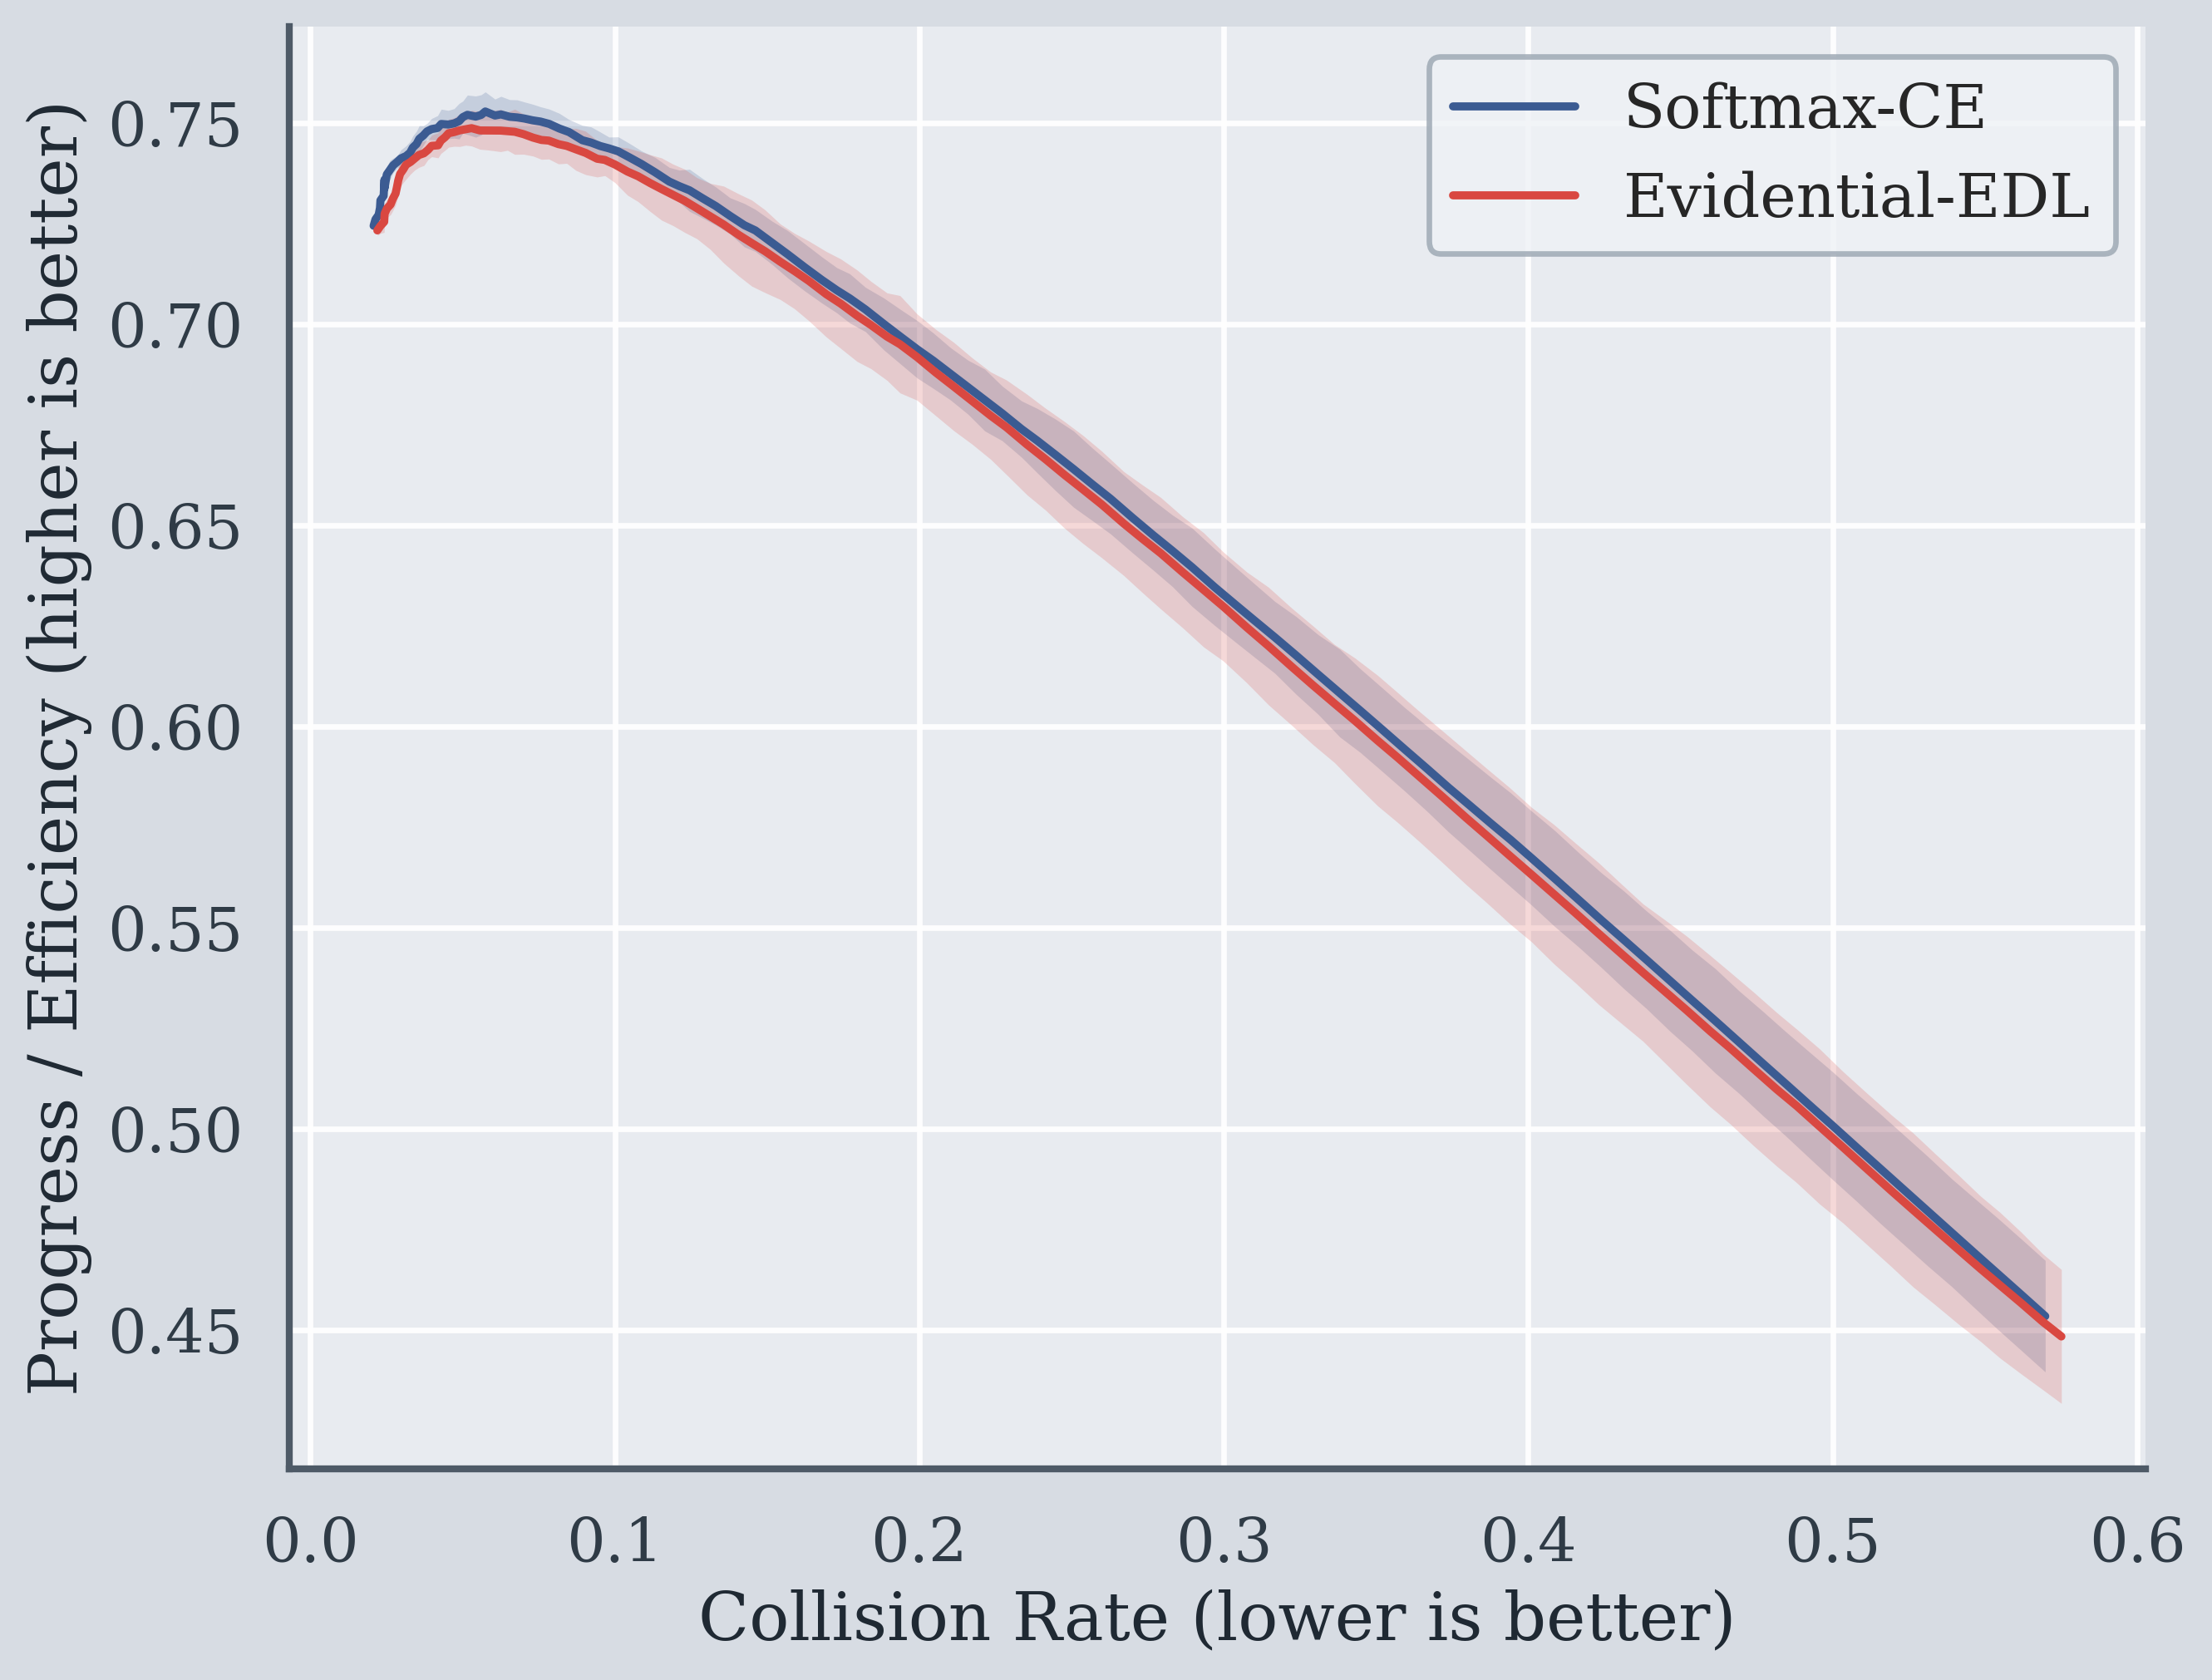

outputs\figures\frontier_ood.png


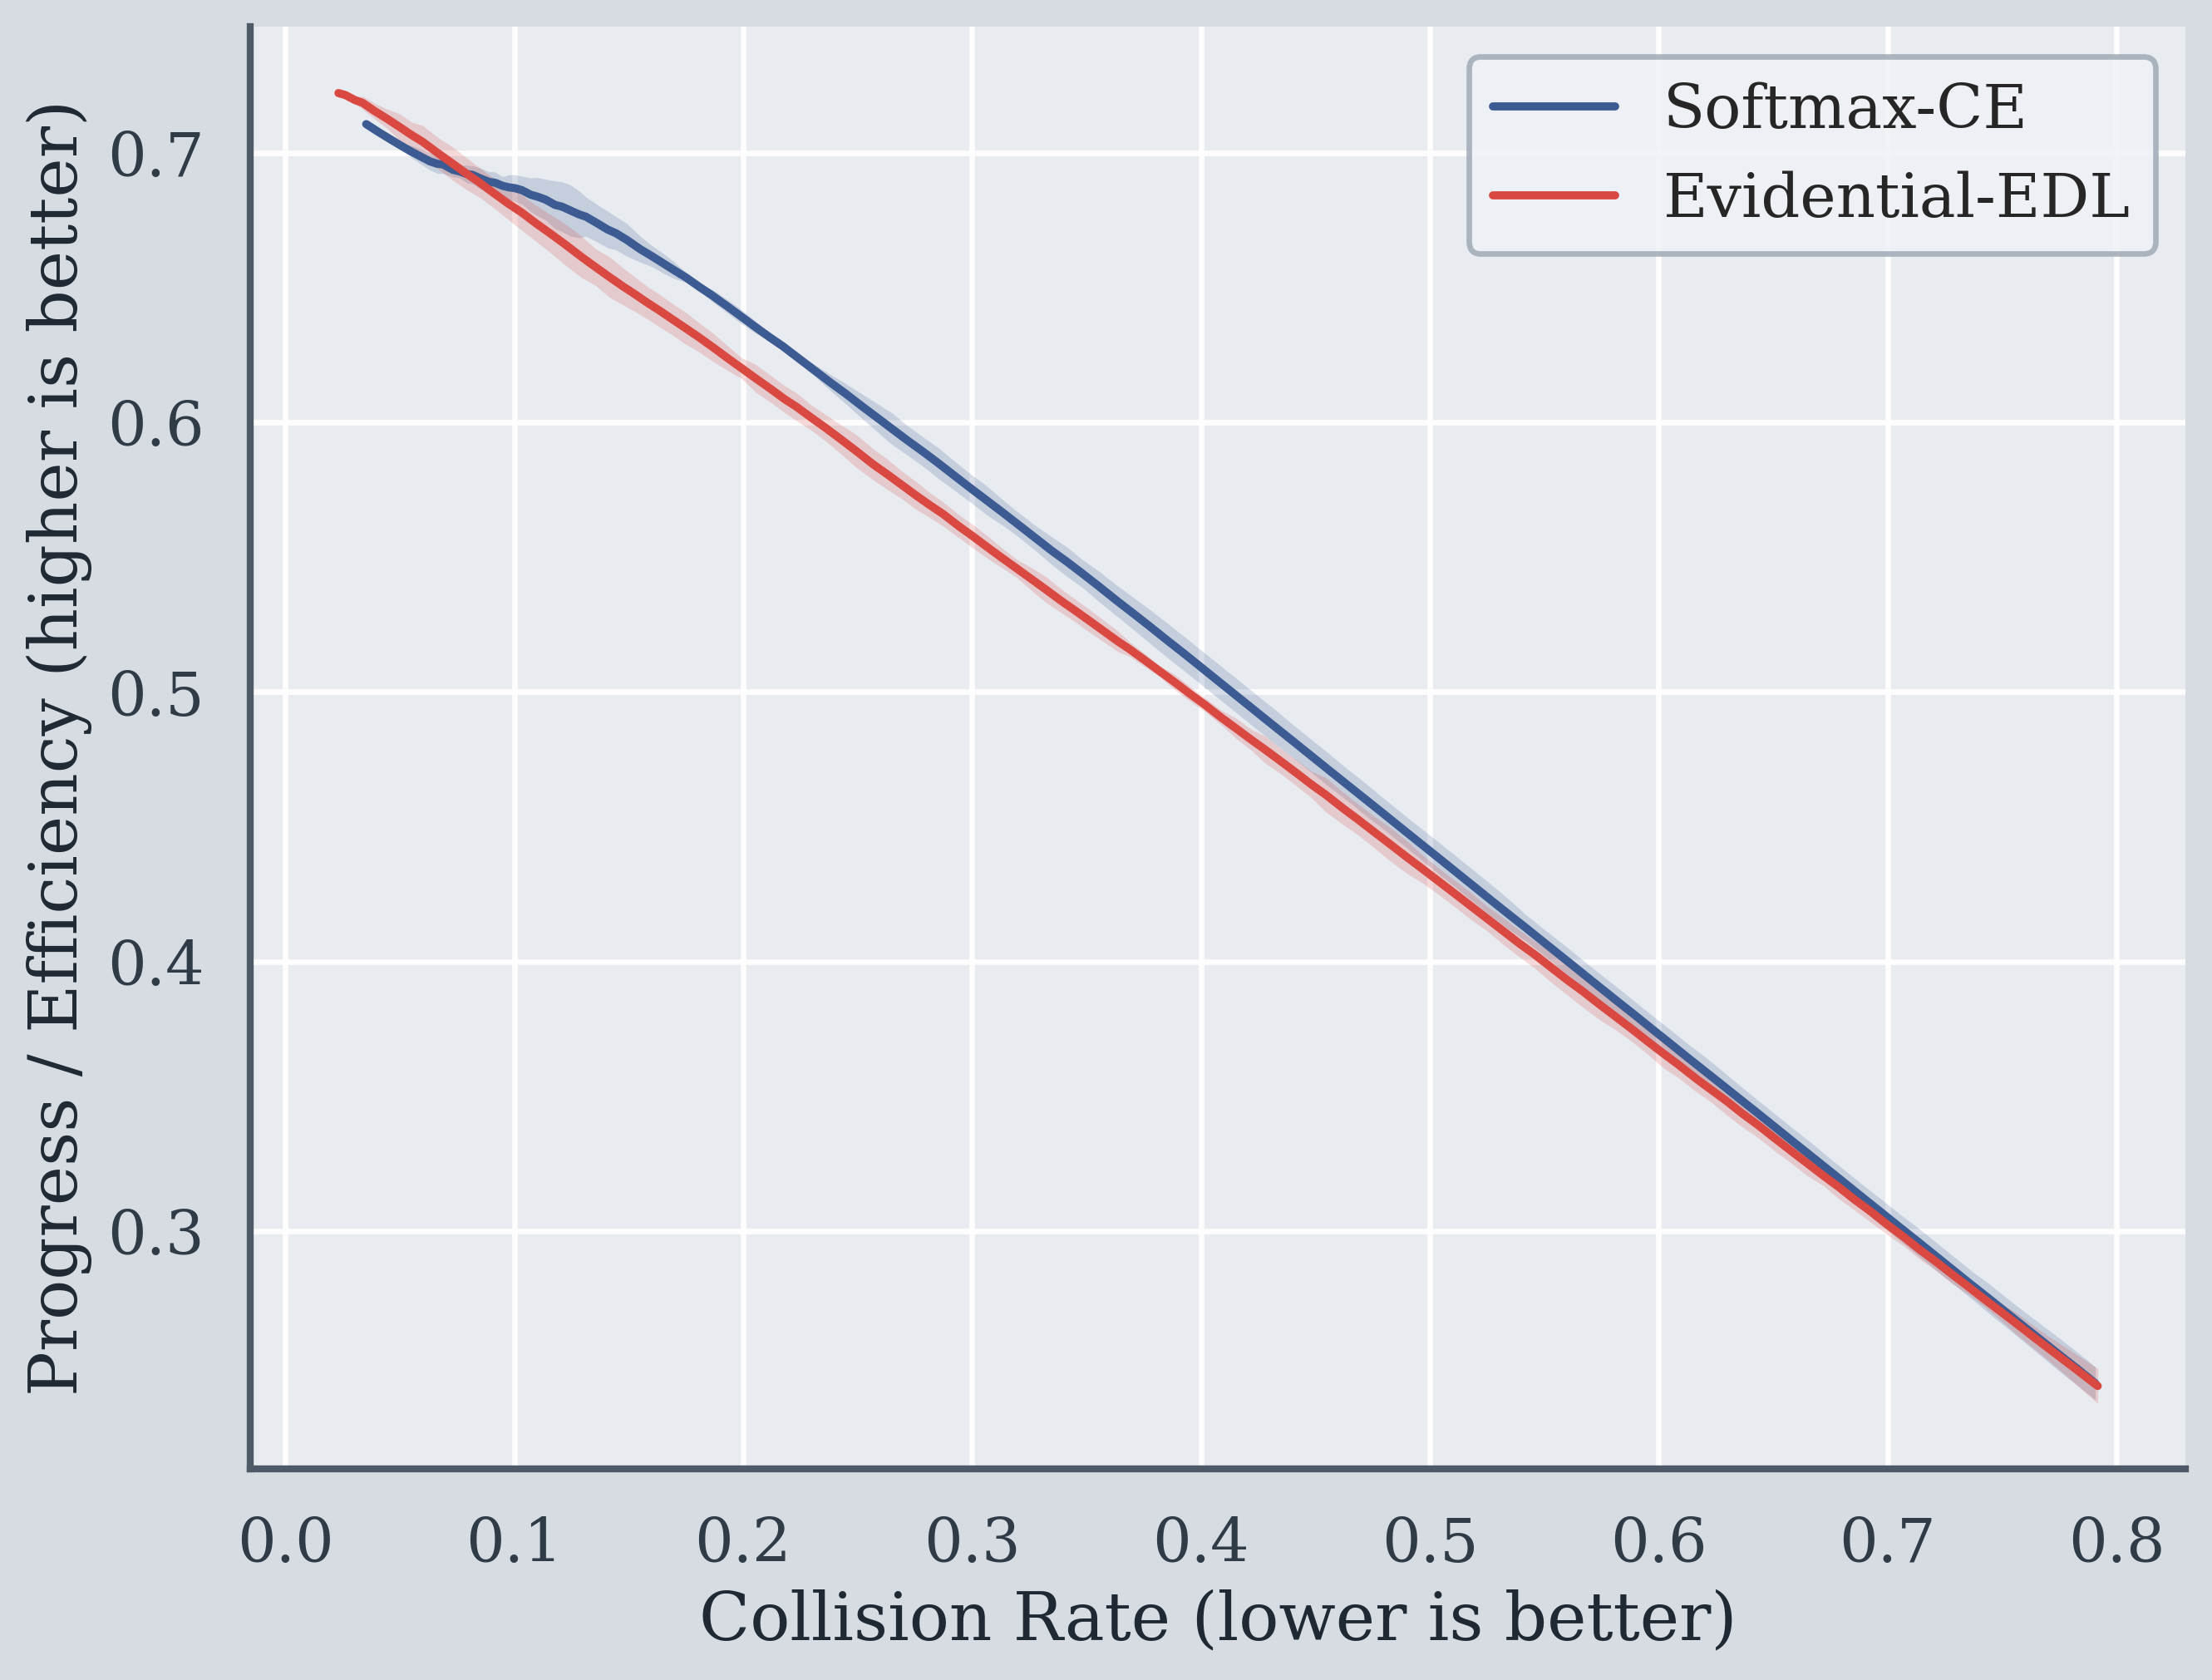

outputs\figures\policy_collision_rate.png


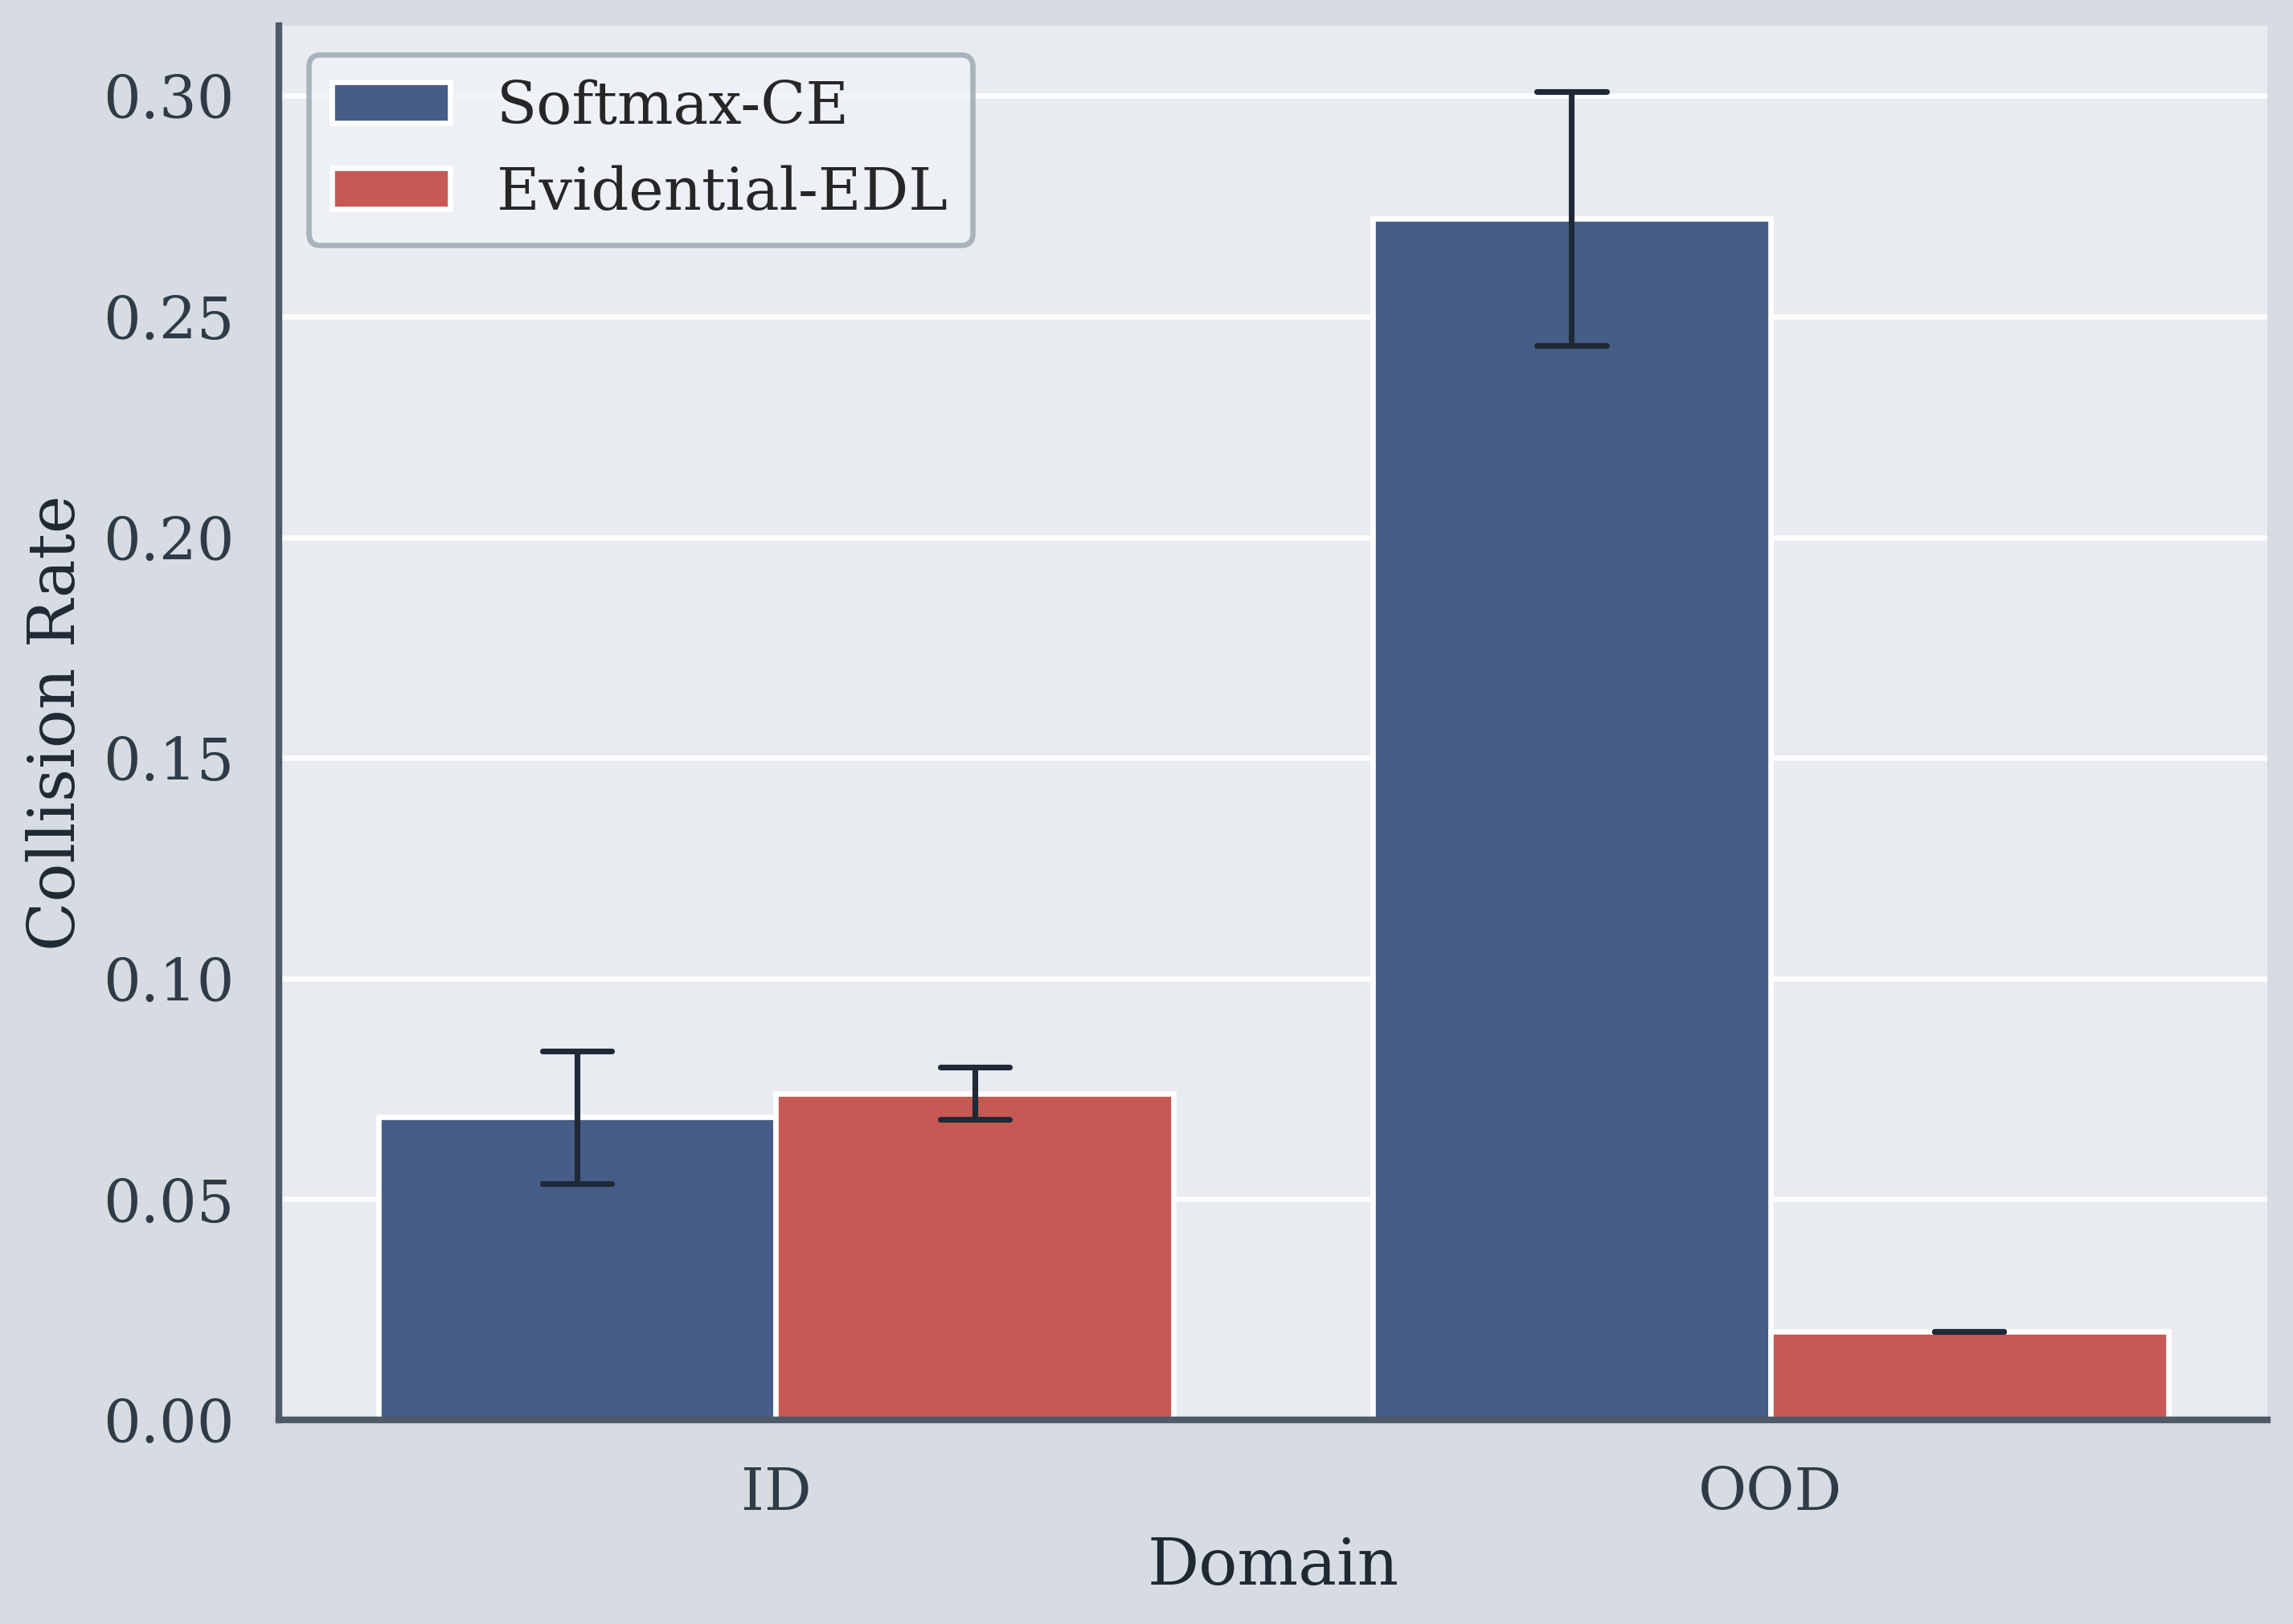

outputs\figures\policy_progress.png


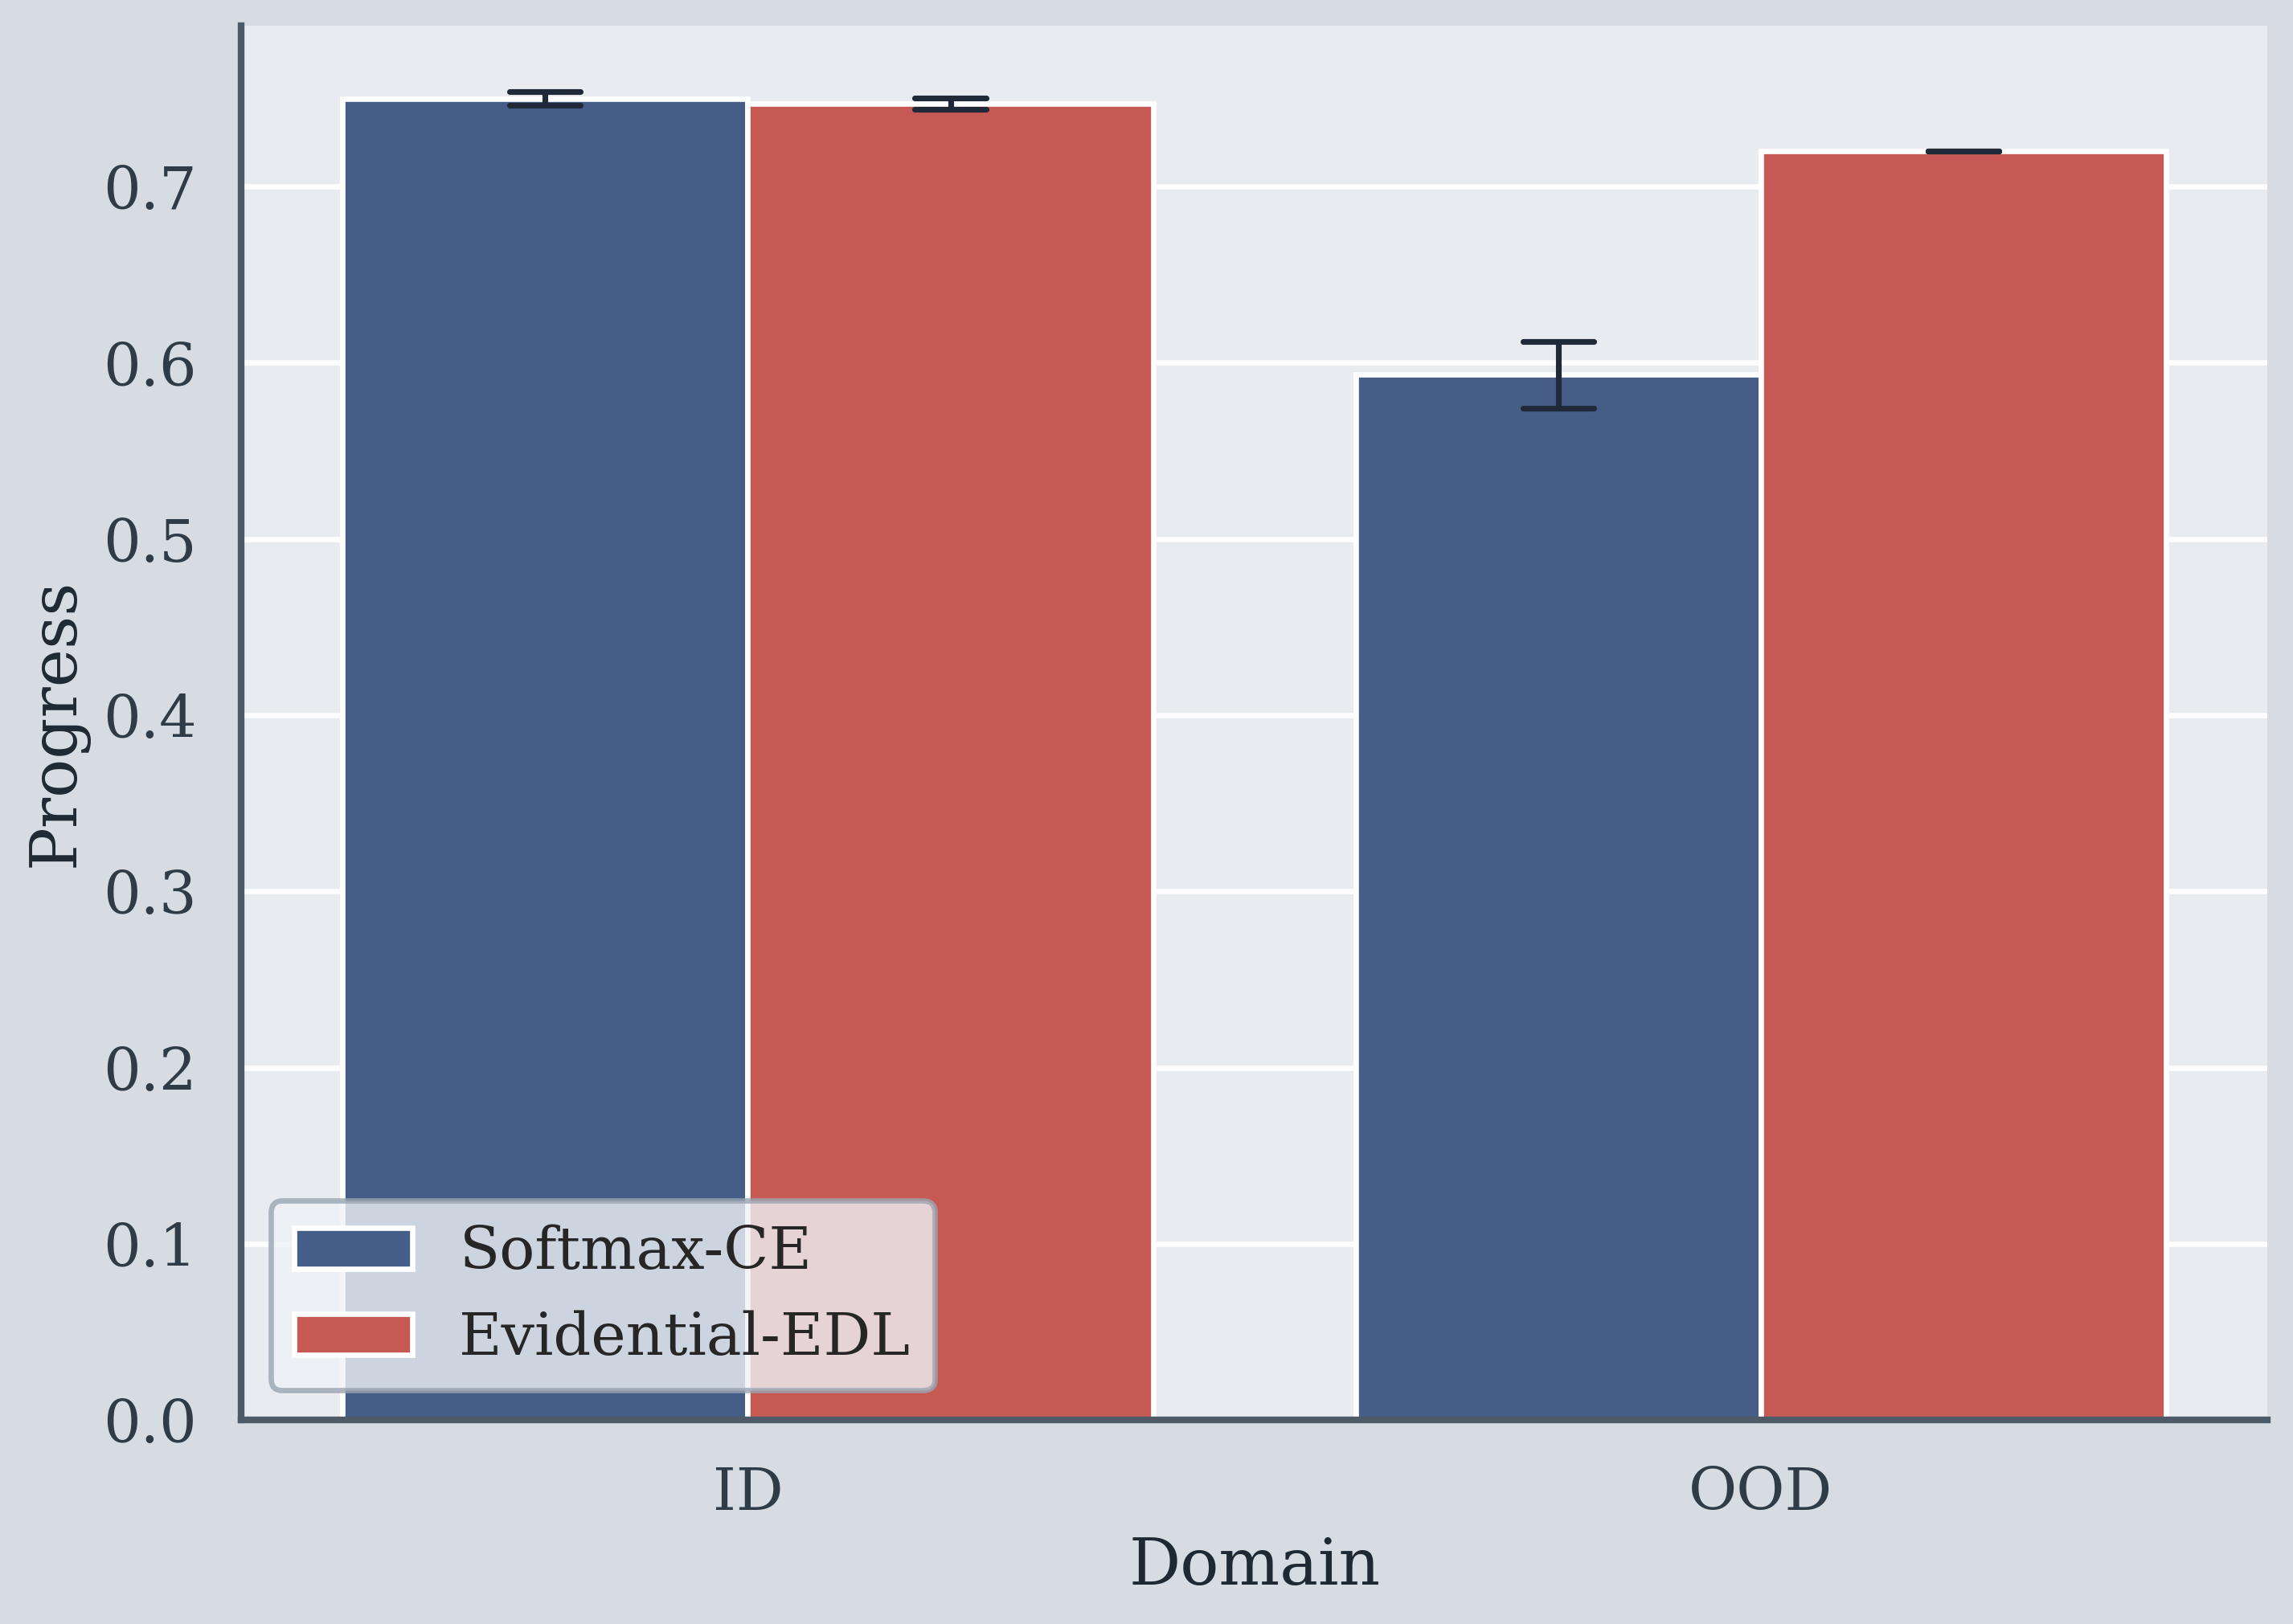

In [4]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

out_path = Path(args.out_dir)
policy_csv = out_path / "policy_outcome_summary.csv"
signal_csv = out_path / "signal_quality_summary.csv"
report_md = out_path / "REPORT.md"

print("[核心输出]")
print(policy_csv)
print(signal_csv)
print(report_md)

if signal_csv.exists():
    print("\n[信号质量汇总]")
    display(pd.read_csv(signal_csv))

if policy_csv.exists():
    print("\n[策略结果汇总]")
    df_policy = pd.read_csv(policy_csv)
    display(df_policy)

fig_dir = out_path / "figures"
for name in ["frontier_id.png", "frontier_ood.png", "policy_collision_rate.png", "policy_progress.png"]:
    p = fig_dir / name
    if p.exists():
        print(p)
        display(Image(filename=str(p)))
